# conflibertR: end-to-end walkthrough

[`conflibertR`](https://github.com/shreyasmeher/conflibertR) is an R interface to **ConfliBERT**, a transformer model purpose-built for conflict and political-violence text. This notebook walks through every major capability of the package and ends with an extended active-learning workflow.

**Sections**

1. Setup (Colab or local)
2. Named Entity Recognition
3. Binary Classification
4. Multilabel Event Classification
5. Question Answering
6. Benchmarking the pretrained classifier
7. Fine-tuning a custom classifier
8. Comparing multiple base models
9. Active Learning (the main event)
    - Sessions, query batches, and labeling
    - Shiny gadget vs. console-only labeling
    - Query strategies (entropy / margin / least confidence)
    - Diversity-aware batches
    - LoRA adapters
    - Saving and reloading the trained model

> **Kernel:** R (via [IRkernel](https://github.com/IRkernel/IRkernel)).
>
> - **On Colab:** *Runtime → Change runtime type → R*, and pick a GPU accelerator (T4 is fine) for fine-tuning + active learning. Then run the **Setup** cells below in order, restart the runtime when prompted, and pick up at the *Post-restart* cell.
> - **Locally:** `install.packages('IRkernel'); IRkernel::installspec()` once, then run the same setup cells (the `system('apt-get …')` cell is Colab-only — skip it).

> **GPU note:** Fine-tuning and active-learning rounds are much faster on GPU but will run on CPU. Inference (NER / classify / multilabel / QA) is fine on CPU.

## 1. Setup

Three steps:

1. Install OS dev libs (Colab only — needed so R can build packages with `curl` / `xml2` / `openssl` deps).
2. Install the R package from GitHub.
3. Install the Python backend.
   - **On Colab** we skip `conflibert_install()` and install the missing Python packages directly into Colab's bundled Python (its `/usr/local/bin/python` can't create a venv, and torch + tensorflow already ship in the runtime — so we only pull `transformers`, `accelerate`, `peft`, `scikit-learn`, `tf-keras`).
   - **Locally**, `conflibert_install(method = 'auto')` picks conda if available, else virtualenv.

After Step 3, **restart the runtime** and pick up at the *Post-restart* cell. Together this is ~2–3 min on Colab (~5–10 min locally if torch has to download).

In [1]:
## Step 1 — Colab only. Skip locally.
## Installs OS dev libs that some R packages link against.
if (file.exists('/etc/lsb-release')) {
  cmd <- 'apt-get update -qq && apt-get install -y --no-install-recommends libcurl4-openssl-dev libssl-dev libxml2-dev'
  status <- system(cmd)
  if (status != 0) {
    message('apt-get returned non-zero (', status, '). On Colab the libs are usually already present — try Step 2 anyway.')
  }
}

In [2]:
# Step 2 — R package from GitHub
if (!requireNamespace('remotes', quietly = TRUE)) install.packages('remotes')
remotes::install_github('shreyasmeher/conflibertR', upgrade = 'never')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Installing 4 packages: png, here, RcppTOML, reticulate

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpspSccc/remotes185636efaec6/shreyasmeher-conflibertR-a2f1f5f/DESCRIPTION’ ... OK
* preparing ‘conflibertR’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘conflibertR_0.4.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
## Step 3 — Python backend.
##
## On Colab, /usr/local/bin/python can't create a venv (no ensurepip),
## so we install deps directly into the system Python. Torch + tensorflow
## already ship with Colab; we only need the missing extras.
##
## Locally with conda available, we use the normal conflibert_install path.
on_colab <- file.exists('/etc/lsb-release') && file.exists('/usr/local/bin/python')

if (on_colab) {
  system('pip install -q "transformers>=4.40,<5" accelerate peft scikit-learn tf-keras')
} else {
  conflibertR::conflibert_install(method = 'auto')
}

### ⚠️ Restart the runtime now

*Runtime → Restart session* (Colab) or restart your R kernel (local). This is required so `conflibertR` picks up the new virtualenv on its next load. Then continue from the **Post-restart** cell below — you do **not** need to re-run the install cells above.

### Post-restart

Load the package and confirm the Python backend is wired up. `conflibert_models()` should return a tibble of available base models without errors.

In [1]:
## On Colab we skipped the venv and installed into the system Python,
## so point reticulate at it before loading the package.
if (file.exists('/etc/lsb-release') && file.exists('/usr/local/bin/python')) {
  Sys.setenv(RETICULATE_PYTHON = '/usr/local/bin/python')
}

library(conflibertR)
conflibert_models()

[1] "ConfliBERT"        "BERT Base Uncased" "BERT Base Cased"  
[4] "RoBERTa Base"      "ModernBERT Base"   "DeBERTa v3 Base"  
[7] "DistilBERT Base"

## 2. Named Entity Recognition

Extract persons, organisations, locations, weapons, and temporal expressions from conflict-related text. Pass a single string or a vector — the function is vectorized.

*The first inference call downloads the model from HuggingFace (~400 MB). Subsequent calls reuse the cached weights.*

In [2]:
conflibert_ner(
  'The United Nations deployed peacekeepers to eastern Congo after rebel forces attacked Goma on Tuesday.'
)

entity,label
<chr>,<chr>
the united nations,Organisation
peacekeepers,Organisation
eastern congo,Location
rebel forces,Organisation
goma,Location
tuesday,Temporal
[SEP],Organisation


In [3]:
conflibert_ner(c(
  'NATO forces launched airstrikes near Tripoli in March 2024.',
  'President Zelenskyy met with General Syrskyi in Kyiv.'
))

doc_id,entity,label
<int>,<chr>,<chr>
1,nato forces,Organisation
1,tripoli,Location
1,march 2024,Temporal
2,president zelenskyy,Person
2,general syrskyi,Person
2,kyiv,Location
2,[SEP],Person


## 3. Binary Classification

Is this text describing a conflict event? Each row gets a label, numeric class, confidence, and per-class probabilities.

In [4]:
conflibert_classify(c(
  'Armed militants stormed a military outpost killing twelve soldiers.',
  'The European Central Bank held interest rates steady at 4.5 percent.',
  'Protesters clashed with riot police outside the parliament building.',
  'A new trade agreement was signed between Japan and Australia.'
))

text,label,class,confidence,prob_negative,prob_positive
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Armed militants stormed a military outpost killing twelve soldiers.,Positive,1,0.9998,0.0002,0.9998
The European Central Bank held interest rates steady at 4.5 percent.,Positive,1,0.9868,0.0132,0.9868
Protesters clashed with riot police outside the parliament building.,Positive,1,0.9964,0.0036,0.9964
A new trade agreement was signed between Japan and Australia.,Positive,1,0.5692,0.4308,0.5692


## 4. Multilabel Event Classification

Score text against four event categories — *Armed Assault*, *Bombing or Explosion*, *Kidnapping*, *Other* — independently. A single text can be flagged for several at once.

In [5]:
conflibert_multilabel(c(
  'A car bomb exploded near the government ministry in Baghdad.',
  'Gunmen kidnapped three aid workers travelling through the Sahel region.'
))

doc_id,text,label,probability,predicted
<int>,<chr>,<chr>,<dbl>,<lgl>
1,A car bomb exploded near the government ministry in Baghdad.,Armed Assault,0.0072,FALSE
1,A car bomb exploded near the government ministry in Baghdad.,Bombing or Explosion,0.9955,TRUE
1,A car bomb exploded near the government ministry in Baghdad.,Kidnapping,0.0038,FALSE
1,A car bomb exploded near the government ministry in Baghdad.,Other,0.0083,FALSE
2,Gunmen kidnapped three aid workers travelling through the Sahel region.,Armed Assault,0.0169,FALSE
2,Gunmen kidnapped three aid workers travelling through the Sahel region.,Bombing or Explosion,0.0249,FALSE
2,Gunmen kidnapped three aid workers travelling through the Sahel region.,Kidnapping,0.9892,TRUE
2,Gunmen kidnapped three aid workers travelling through the Sahel region.,Other,0.0189,FALSE


## 5. Question Answering

Extractive QA — pull spans directly out of a passage.

In [6]:
context <- 'On 15 September 2023, ethnic clashes erupted in Manipur, India.
  The Indian Army deployed two battalions to restore order.
  At least 60 people were killed and over 200 injured in the violence.'

conflibert_qa(context, 'How many people were killed?')
conflibert_qa(context, 'Who was deployed to restore order?')
conflibert_qa(context, 'Where did the clashes occur?')

[1] "At least 60"

[1] "two battalions"

[1] "Manipur, India"

## 6. Benchmarking the pretrained classifier

Evaluate the pretrained ConfliBERT binary classifier on labeled data. The package ships small example datasets you can use to get started.

In [7]:
data <- conflibert_example('binary')
str(data, max.level = 2)

List of 3
 $ train:'data.frame':	81 obs. of  2 variables:
  ..$ text : chr [1:81] "Government forces launched an offensive against rebel positions in the northern province early this morning" "A car bomb exploded near a military checkpoint killing at least twelve soldiers" "Insurgents attacked a police station in the capital overnight leaving several officers wounded" "The militant group claimed responsibility for the ambush on a military convoy" ...
  ..$ label: int [1:81] 1 1 1 1 1 1 1 1 1 1 ...
 $ dev  :'data.frame':	20 obs. of  2 variables:
  ..$ text : chr [1:20] "The peacekeeping mission reported increased hostilities along the ceasefire line" "The warlord's militia seized control of the strategically important bridge" "The naval forces intercepted a shipment of weapons destined for the rebels" "The terrorist organization released a video threatening further attacks" ...
  ..$ label: int [1:20] 1 1 1 1 1 1 1 1 1 1 ...
 $ test :'data.frame':	20 obs. of  2 variables:
  ..$ text : c

In [8]:
bench <- conflibert_benchmark(data$test$text, data$test$label)
bench

accuracy,precision,recall,f1,n
<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,1,1,1,20


## 7. Fine-tuning a custom classifier

Train your own binary classifier on labeled data. The bundled example has 80 train / 20 dev / 20 test examples.

*This is the first cell that really wants a GPU. On a T4 it finishes in under a minute; on CPU it can take 5–10 minutes.*

In [9]:
result <- conflibert_finetune(
  train  = data$train,
  dev    = data$dev,
  test   = data$test,
  model  = 'ConfliBERT',
  task   = 'binary',
  epochs = 3
)

cat('Accuracy:', result$metrics$accuracy, '\n')
cat('F1 Score:', result$metrics$f1, '\n')

Accuracy: 0.8 
F1 Score: 0.8333 


In [10]:
head(result$predictions)
head(result$probabilities)
result$model_dir   # NULL unless save_dir was set

[1] 1 1 1 1 1 1

0.27570453,0.7242955
0.14880568,0.8511943
0.09691224,0.9030878
0.11661786,0.8833821
0.14878139,0.8512186
0.18706395,0.8129361


[1] "/tmp/conflibert_r_h3fwfqub"

### Multiclass fine-tuning

The bundled multiclass dataset has four event types: *Diplomacy*, *Armed Conflict*, *Protest*, *Humanitarian*.

In [ ]:
mc_data <- conflibert_example('multiclass')

mc_result <- conflibert_finetune(
  train  = mc_data$train,
  dev    = mc_data$dev,
  test   = mc_data$test,
  model  = 'ConfliBERT',
  task   = 'multiclass',
  epochs = 3
)

cat('Multiclass Accuracy:', mc_result$metrics$accuracy, '\n')
cat('Multiclass F1:      ', mc_result$metrics$f1, '\n')

## 8. Comparing multiple base models

Pit ConfliBERT against general-purpose transformers on the same task. `conflibert_compare()` fine-tunes each one and returns a tidy comparison table.

*This trains three models in sequence — expect ~3× the time of the single fine-tune above.*

In [ ]:
comparison <- conflibert_compare(
  train  = data$train,
  dev    = data$dev,
  test   = data$test,
  models = c('ConfliBERT', 'BERT Base Uncased', 'DistilBERT Base'),
  task   = 'binary',
  epochs = 3
)
comparison

## 9. Active Learning

Labeling text is expensive. Active learning lets you spend annotation effort on the examples a model is *most uncertain* about, so each label has maximum impact on performance.

The conflibertR loop:

1. Start from a tiny labeled seed and an unlabeled pool.
2. Train a model on the seed; the package returns the most uncertain samples from the pool.
3. Label those samples, submit them, and the model retrains and picks the next uncertain batch.
4. Repeat until the pool is exhausted or metrics plateau.
5. Save the final model as a HuggingFace checkpoint.

The whole loop is three functions: `conflibert_active_start()`, `conflibert_active_next()`, `conflibert_active_save()`. A fourth — `conflibert_active_label()` — opens an interactive labeling UI (skip it on Colab; we use the oracle below).

### 9.1 Example data

The package bundles a small demo dataset: a 20-text labeled seed, a 61-text unlabeled pool, and a dev set. It also includes oracle labels for the pool so we can simulate a full loop without a human in the loop. **In a real workflow you'd label `session$query` yourself; the oracle is for testing only.**

In [11]:
demo <- conflibert_example('active')

cat('Seed (labeled): ', nrow(demo$seed), '\n')
cat('Pool (unlabeled):', length(demo$pool), '\n')
cat('Dev:             ', nrow(demo$dev), '\n')
cat('Oracle labels:   ', length(demo$pool_labels), '(simulation only)\n')

head(demo$seed)

Seed (labeled):  20 
Pool (unlabeled): 61 
Dev:              20 
Oracle labels:    61 (simulation only)


,text,label
,<chr>,<int>
1,Astronomers observed a rare celestial event visible from the southern hemisphere,0
2,Sniper fire killed two civilians in the besieged neighborhood,1
3,A major software update was released improving performance and adding new features,0
4,The airline announced new direct flights connecting the capital with European cities,0
5,Security operations intensified after a series of bombings in the commercial district,1
6,Protesters clashed violently with police during demonstrations against the military regime,1


### 9.2 Starting a session

`conflibert_active_start()` trains a classifier on the seed and returns a session object containing the first uncertain batch.

In [12]:
session <- conflibert_active_start(
  seed       = demo$seed,
  pool       = demo$pool,
  dev        = demo$dev,
  model      = 'ConfliBERT',
  task       = 'binary',
  strategy   = 'entropy',     # or 'margin', 'least_confidence'
  query_size = 10,
  epochs     = 1
)

session

Active learning session  (round 1)
  Model: ConfliBERT  |  Task: binary  |  Strategy: entropy
  Labeled: 20  |  Pool remaining: 51  |  Query size: 10

Metrics by round:
# A tibble: 1 × 12
  round train_size  loss accuracy precision recall    f1 runtime
  <int>      <int> <dbl>    <dbl>     <dbl>  <dbl> <dbl>   <dbl>
1     0         20 0.812     0.45         0      0     0  0.0313
# ℹ 4 more variables: samples_per_second <dbl>, steps_per_second <dbl>,
#   uncertainty_mean <dbl>, uncertainty_max <dbl>

Current query (10 samples, showing 5):
# A tibble: 5 × 2
  text                                                               uncertainty
  <chr>                                                                    <dbl>
1 Ethnic tensions erupted into open violence as rival communities c…       0.692
2 The museum opened a new exhibition showcasing contemporary sculpt…       0.692
3 Military helicopters were deployed to support ground troops fight…       0.691
4 A new study found that regular

What's in a session:

- `session$query` — tibble of texts to label next, with an `uncertainty` column.
- `session$metrics` — per-round dev metrics (accuracy, F1) tracked across rounds.
- `session$labeled_n` / `session$pool_n` — progress counters.
- `session$done` — `TRUE` once the pool is exhausted.

In [13]:
session$query

text,uncertainty
<chr>,<dbl>
Ethnic tensions erupted into open violence as rival communities clashed in the market,0.6919
The museum opened a new exhibition showcasing contemporary sculpture and painting,0.6918
Military helicopters were deployed to support ground troops fighting in the eastern region,0.6906
A new study found that regular exercise significantly reduces heart disease risk,0.6896
The opposition forces breached the defensive perimeter around the government compound,0.6856
Researchers published findings on a promising treatment for a rare disorder,0.6825
Government forces launched an offensive against rebel positions in the northern province early this morning,0.6734
The city council approved plans for a new public park in the downtown area,0.6622
The rebel forces captured a strategic town after weeks of intense battles,0.6584


In [14]:
session$metrics

round,train_size,loss,accuracy,precision,recall,f1,runtime,samples_per_second,steps_per_second,uncertainty_mean,uncertainty_max
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,20,0.8125,0.45,0,0,0,0.0313,638.315,63.831,0.6779,0.6919


### 9.3 Labeling and iterating

**Option A — Shiny gadget (real labeling, local R).** Opens a modal dialog with radio buttons for each class. Skip on Colab — the gadget needs an interactive desktop session.

```r
labels  <- conflibert_active_label(session)
session <- conflibert_active_next(session, labels = labels)
```

**Option B — by hand.** Provide a vector in the same order as `session$query`:

```r
labels  <- c(1, 0, 1, 0, 0, 1, 0, 1, 0, 1)
session <- conflibert_active_next(session, labels = labels)
```

**Option C — oracle simulation (this notebook).** We use the bundled oracle so the notebook runs end-to-end on Colab without any human labeling:

In [15]:
labels  <- unname(demo$pool_labels[session$query$text])
session <- conflibert_active_next(session, labels = labels)
session

Active learning session  (round 2)
  Model: ConfliBERT  |  Task: binary  |  Strategy: entropy
  Labeled: 30  |  Pool remaining: 41  |  Query size: 10

Metrics by round:
# A tibble: 2 × 12
  round train_size  loss accuracy precision recall    f1 runtime
  <int>      <int> <dbl>    <dbl>     <dbl>  <dbl> <dbl>   <dbl>
1     0         20 0.812     0.45         0    0   0      0.0313
2     1         30 0.621     0.7          1    0.4 0.571  0.0326
# ℹ 4 more variables: samples_per_second <dbl>, steps_per_second <dbl>,
#   uncertainty_mean <dbl>, uncertainty_max <dbl>

Current query (10 samples, showing 5):
# A tibble: 5 × 2
  text                                                               uncertainty
  <chr>                                                                    <dbl>
1 The armed group kidnapped aid workers operating in the conflict z…       0.693
2 Armed bandits attacked a refugee camp displacing thousands of peo…       0.693
3 Insurgents attacked a police station in the ca

Now run a few more rounds. Each round trains on the growing labeled set and queries a fresh uncertain batch. We stop early if the pool is exhausted (`session$done`).

In [16]:
for (round in 2:5) {
  if (session$done) break
  labels  <- unname(demo$pool_labels[session$query$text])
  session <- conflibert_active_next(session, labels = labels)
  cat(sprintf('Round %d  labeled=%d  pool=%d\n',
              round, session$labeled_n, session$pool_n))
}

session$metrics

Round 2  labeled=40  pool=31
Round 3  labeled=50  pool=21
Round 4  labeled=60  pool=11
Round 5  labeled=70  pool=1


round,train_size,loss,accuracy,precision,recall,f1,runtime,samples_per_second,steps_per_second,uncertainty_mean,uncertainty_max
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,20,0.8125,0.45,0.000,0.0,0.0000,0.0313,638.315,63.831,0.6779,0.6919
1,30,0.6212,0.70,1.000,0.4,0.5714,0.0326,614.352,61.435,0.6926,0.6931
2,40,0.5877,0.80,1.000,0.6,0.7500,0.0320,625.479,62.548,0.6910,0.6928
3,50,0.6102,0.70,0.625,1.0,0.7692,0.0319,626.287,62.629,0.6911,0.6931
4,60,0.5838,0.70,0.625,1.0,0.7692,0.0314,636.441,63.644,0.6920,0.6930
5,70,0.5936,0.65,1.000,0.3,0.4615,0.0386,518.526,51.853,0.6727,0.6925


### 9.4 Visualizing progress

`plot()` produces a two-panel diagnostic: the learning curve on top (metrics vs. labeled-set size) and the query uncertainty trend on the bottom. When mean uncertainty flattens, the model is no longer finding informative samples — a good signal to stop labeling.

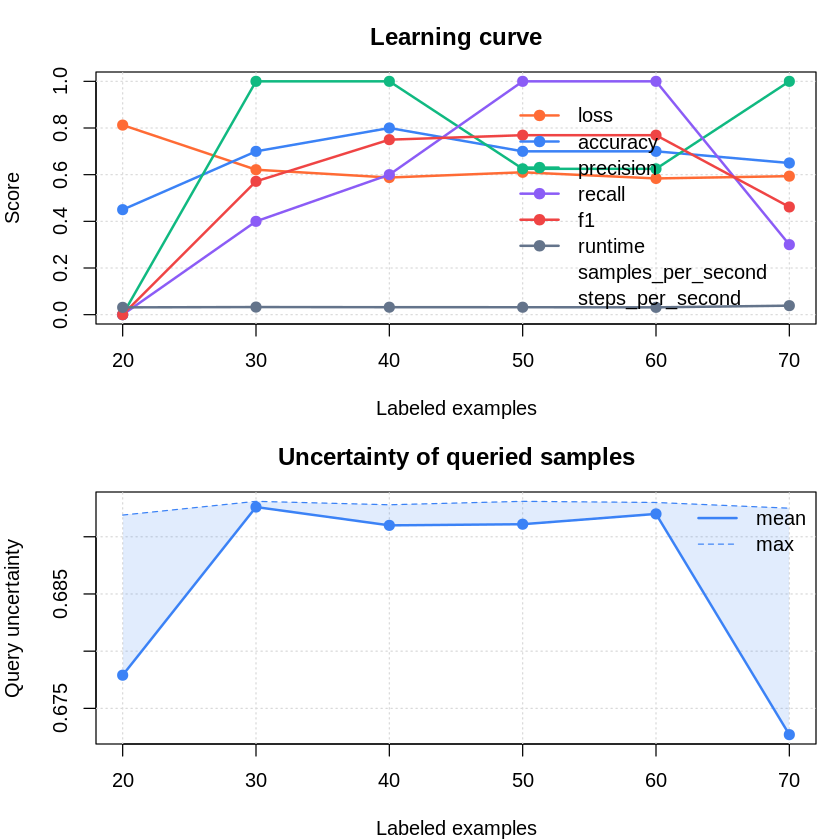

In [17]:
plot(session)

# Or a single panel:
# plot(session, which = 'metrics')
# plot(session, which = 'uncertainty')

### 9.5 Query strategies

Three uncertainty strategies, picked at `conflibert_active_start()` time via `strategy =`:

| Strategy            | Picks samples with…                                 | When to use                          |
|---------------------|------------------------------------------------------|--------------------------------------|
| `entropy` (default) | highest Shannon entropy of class probs              | binary or multiclass; safe default   |
| `margin`            | smallest gap between top-two class probs            | targets decision-boundary cases      |
| `least_confidence`  | lowest max class prob                               | simplest baseline                    |

Restart with a different strategy whenever you like:

In [ ]:
session_margin <- conflibert_active_start(
  seed = demo$seed, pool = demo$pool, dev = demo$dev,
  strategy = 'margin', query_size = 10, epochs = 1
)
head(session_margin$query)

### 9.6 Diversity-aware batches

Pure uncertainty sampling can pick several near-duplicates in one batch — wasteful when your pool has many similar texts. Pass `diverse = TRUE` to cluster the top-scoring candidates in the model's embedding space and pick the highest-scoring sample from each cluster.

In [18]:
session_div <- conflibert_active_start(
  seed = demo$seed, pool = demo$pool, dev = demo$dev,
  strategy             = 'entropy',
  diverse              = TRUE,
  diversity_candidates = 30,   # defaults to 3 * query_size
  query_size           = 10,
  epochs               = 1
)
head(session_div$query)

text,uncertainty
<chr>,<dbl>
An airstrike destroyed a weapons depot used by the insurgent group,0.6550
The city council approved plans for a new public park in the downtown area,0.6700
Temperatures are expected to reach record highs this weekend according to forecasters,0.6346
Military helicopters were deployed to support ground troops fighting in the eastern region,0.6927
Scientists discovered a new species of deep-sea fish in the Pacific Ocean,0.6716
The separatist movement launched coordinated attacks on government installations,0.6615


### 9.7 LoRA fine-tuning

For bigger base models or tighter GPU budgets, train only a low-rank adapter each round. The adapter is merged into the base model before every round ends, so scoring, saving, and reloading behave exactly like full fine-tuning.

In [ ]:
session_lora <- conflibert_active_start(
  seed = demo$seed, pool = demo$pool, dev = demo$dev,
  model      = 'DeBERTa v3 Base',
  use_lora   = TRUE,
  lora_rank  = 8,
  lora_alpha = 16,
  query_size = 10,
  epochs     = 1
)
session_lora

### 9.8 Saving and reloading the model

Persist the final model as a standard HuggingFace checkpoint. On Colab, save into `/content` and download it (or push to the HuggingFace Hub) before the runtime is recycled.

In [ ]:
save_dir <- if (file.exists('/etc/lsb-release')) '/content/my_al_model' else 'my_al_model'
conflibert_active_save(session, save_dir)
list.files(save_dir)

Reload it from any `transformers` tool — for example from Python:

```python
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model = AutoModelForSequenceClassification.from_pretrained('/content/my_al_model')
tok   = AutoTokenizer.from_pretrained('/content/my_al_model')
```

## Tips

- **Start small.** A seed of 10–50 texts is often enough; active learning shines when the pool is much larger than the labeled set.
- **Watch uncertainty trends, not just metrics.** If dev metrics are noisy on small sets, the uncertainty panel often tells a clearer story about whether the model is still learning.
- **Parameters carry across rounds.** Model, task, strategy, query size, and training hyperparameters are fixed at `conflibert_active_start()` time and reused for every subsequent round.
- **Sessions are in-memory.** The trained model lives inside the session object as a Python handle. `saveRDS()` won't serialize it — use `conflibert_active_save()` to persist, and re-run rounds from a fresh session if needed.
- **Colab runtimes are ephemeral.** Anything in `/content` disappears when the runtime is recycled. Download saved models or push them to the Hub.

## Function reference

| Function                       | Task                                       |
|--------------------------------|--------------------------------------------|
| `conflibert_ner()`             | Named entity recognition                   |
| `conflibert_classify()`        | Binary conflict classification             |
| `conflibert_multilabel()`      | Multilabel event type scoring              |
| `conflibert_qa()`              | Extractive question answering              |
| `conflibert_benchmark()`       | Evaluate the pretrained classifier         |
| `conflibert_finetune()`        | Train a custom classifier                  |
| `conflibert_compare()`         | Compare multiple model architectures       |
| `conflibert_example()`         | Load bundled example datasets              |
| `conflibert_models()`          | List available base models                 |
| `conflibert_active_start()`    | Start an active-learning session           |
| `conflibert_active_next()`     | Submit labels, get next query batch        |
| `conflibert_active_label()`    | Shiny gadget for interactive labeling      |
| `conflibert_active_save()`     | Save the final model as HF checkpoint      |

Reference: Brandt et al. (2025), *Extractive versus Generative Language Models for Political Conflict Text Classification*, **Political Analysis**.